# Notebook 31 - Probabilistic local mechanics prototype

This notebook implements a first runnable variant of the idea in `ultratimtrack_probabiliste_mecanique_locale.pdf` using the current working Python code.

The PDF describes three levels:

1. adaptive global UltraTimTrack: use speckle confidence to adapt measurement noise
2. local mechanics: estimate a local displacement field, strain, strain rate, confidence, and warnings
3. full mechanics-informed probabilistic model: FEM/MAP prior plus posterior strain uncertainty

Notebook 30 already tested level 1. This notebook starts level 2.

What this notebook does:

- uses the current final-output path for `ANG_deg`, `PEN_deg`, and `FL_mm`
- estimates local speckle block displacements inside the fascicle ROI
- fits a smooth local affine displacement model as a reduced mechanical basis
- derives fiber-direction strain, transverse strain, shear, strain rate, and uncertainty proxies
- produces visual audits of selected frames, including low-confidence or suspicious frames

What this notebook does not do yet:

- it does not implement a full FEM stiffness matrix `Kmech`
- it does not replace the main `ultrasound_tracker` pipeline
- it does not claim clinical strain validity yet

Think of this as a bridge between the current UltraTimTrack-compatible output and a future probabilistic mechanics-informed tracker.

In [1]:
from pathlib import Path
import sys
import os
import math
import json

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

current = Path.cwd()
if (current / "ultrasound_tracker").exists():
    PROJECT_ROOT = current
elif (current.parent / "ultrasound_tracker").exists():
    PROJECT_ROOT = current.parent
else:
    raise FileNotFoundError("Could not find ultrasound_tracker folder")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ultrasound_tracker.roi import load_rois
from ultrasound_tracker.speckle import SpeckleCoherenceParams

plt.style.use("default")
pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/grosbedou/PycharmProjects/NDORMS


## 1. Load current final outputs

This notebook keeps the current final-output path as the reference signal. The local mechanics layer is computed around it; it does not use the old selected-line debug angle.

In [2]:
VIDEO_NAME = "Test2"

VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / f"{VIDEO_NAME}.mp4"
ROI_PATH = PROJECT_ROOT / "data" / "rois" / f"{VIDEO_NAME}_rois.json"
FEATURE_NPZ = PROJECT_ROOT / "results" / f"{VIDEO_NAME}_timtrack_final_features_arrays.npz"

if not VIDEO_PATH.exists() or not ROI_PATH.exists() or not FEATURE_NPZ.exists():
    VIDEO_NAME = "UltraTimTrack_test"
    VIDEO_PATH = PROJECT_ROOT / "data" / "raw" / "UltraTimTrack_test.mp4"
    ROI_PATH = PROJECT_ROOT / "data" / "rois" / "UltraTimTrack_test_rois.json"
    FEATURE_NPZ = PROJECT_ROOT / "results" / "timtrack_sequence_dohough_alpha_features_arrays.npz"

OUT_DIR = PROJECT_ROOT / "results" / "probabilistic_local_mechanics"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV = OUT_DIR / f"{VIDEO_NAME}_local_mechanics_summary.csv"
OUT_NPZ = OUT_DIR / f"{VIDEO_NAME}_local_mechanics_summary.npz"
EXAMPLE_DIR = OUT_DIR / f"{VIDEO_NAME}_examples"
EXAMPLE_DIR.mkdir(parents=True, exist_ok=True)

for label, path in [
    ("VIDEO_PATH", VIDEO_PATH),
    ("ROI_PATH", ROI_PATH),
    ("FEATURE_NPZ", FEATURE_NPZ),
    ("OUT_DIR", OUT_DIR),
]:
    print(label, path, "exists=", path.exists())

VIDEO_PATH /Users/grosbedou/PycharmProjects/NDORMS/data/raw/Test2.mp4 exists= True
ROI_PATH /Users/grosbedou/PycharmProjects/NDORMS/data/rois/Test2_rois.json exists= True
FEATURE_NPZ /Users/grosbedou/PycharmProjects/NDORMS/results/Test2_timtrack_final_features_arrays.npz exists= True
OUT_DIR /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics exists= True


In [3]:
data = np.load(FEATURE_NPZ, allow_pickle=True)
rois = load_rois(ROI_PATH)

frame = np.asarray(data["frame"], dtype=int)
time_s = np.asarray(data["time_s"], dtype=float) if "time_s" in data.files else frame.astype(float)
success = np.asarray(data["success"], dtype=bool) if "success" in data.files else np.ones(len(frame), dtype=bool)


def first_finite_key(keys, min_fraction=0.5):
    for key in keys:
        if key in data.files:
            arr = np.asarray(data[key], dtype=float)
            if np.mean(np.isfinite(arr)) >= min_fraction:
                return key, arr
    raise KeyError(f"None of these keys had enough finite values: {keys}")

ang_key, raw_ang = first_finite_key(["ANG_deg", "fascicle_angle_deg"])
pen_key, raw_pen = first_finite_key(["PEN_deg", "pennation_angle_deg"])
fl_key, raw_fl = first_finite_key(["FL_mm", "FL_px", "fascicle_length_px", "final_fascicle_length_px"])
length_units = "mm" if fl_key == "FL_mm" else "px"
super_angle = np.asarray(data["super_apo_angle_deg"], dtype=float) if "super_apo_angle_deg" in data.files else raw_ang - raw_pen

frame_to_result_idx = {int(f): i for i, f in enumerate(frame)}
median_dt = float(np.nanmedian(np.diff(time_s))) if len(time_s) > 1 else 1.0

print("Loaded frames:", len(frame))
print("Success rate:", float(np.mean(success)))
print("ANG source:", ang_key)
print("PEN source:", pen_key)
print("FL source:", fl_key, f"({length_units})")
print("Fascicle ROI:", rois["fascicle"])
print("Median dt:", median_dt)

Loaded frames: 2667
Success rate: 0.9992500937382827
ANG source: ANG_deg
PEN source: PEN_deg
FL source: FL_mm (mm)
Fascicle ROI: (21, 70, 681, 221)
Median dt: 0.029993057250976562


## 2. Local mechanics model used here

For each pair of frames, block matching estimates local displacements:

```text
y_i(t) = [dx_i, dy_i]
```

Then we fit a reduced affine displacement field:

```text
u_x(x, y) = b0 + b1*x + b2*y
u_y(x, y) = c0 + c1*x + c2*y
```

This is a small reduced basis: translation plus local linear deformation. It is not full FEM, but it is the simplest mechanics-compatible step because it gives a displacement gradient:

```text
grad(u) = [[dux/dx, dux/dy], [duy/dx, duy/dy]]
strain = 0.5 * (grad(u) + grad(u).T)
```

Fiber strain is then computed along the current final fascicle orientation `ANG_deg`:

```text
eps_f = a.T @ strain @ a
```

The confidence and residuals tell us whether the local speckle field agrees with a smooth mechanical deformation.

In [4]:
# Block matching parameters. These are intentionally close to Notebook 30.
BLOCK_SIZE = 21
BLOCK_STRIDE = 28
SEARCH_RADIUS = 12
RHO_MIN = 0.55
MAX_DISPLACEMENT_PX = 16.0
SIGMA_REF_PX = 2.0
CONFIDENCE_MIN = 0.05

speckle_params = SpeckleCoherenceParams(
    block_size=BLOCK_SIZE,
    stride=BLOCK_STRIDE,
    search_radius=SEARCH_RADIUS,
    rho_min=RHO_MIN,
    max_displacement_px=MAX_DISPLACEMENT_PX,
    sigma_ref_px=SIGMA_REF_PX,
    confidence_min=CONFIDENCE_MIN,
)

# To keep this notebook fast, analyze a representative subset by default.
# Lower ANALYSIS_STRIDE for denser time-series; set MAX_ANALYSIS_PAIRS=None for all sampled frames.
ANALYSIS_STRIDE = 20
MAX_ANALYSIS_PAIRS = 180

# Affine mechanics settings.
AFFINE_RIDGE = 1e-3
LOCAL_STRAIN_RADIUS_PX = 70.0
MIN_LOCAL_NEIGHBORS = 8

print(speckle_params)
print("ANALYSIS_STRIDE =", ANALYSIS_STRIDE)
print("MAX_ANALYSIS_PAIRS =", MAX_ANALYSIS_PAIRS)

SpeckleCoherenceParams(block_size=21, stride=28, search_radius=12, rho_min=0.55, max_displacement_px=16.0, sigma_ref_px=2.0, confidence_min=0.05)
ANALYSIS_STRIDE = 20
MAX_ANALYSIS_PAIRS = 180


## 3. Helper functions

The block-matching function below returns the local measurements, not only one global confidence value. The formulas mirror the current package speckle coherence code, but this notebook keeps the per-block data so we can estimate local mechanics.

In [5]:
def read_gray_frames(video_path, frame_numbers):
    frame_numbers = sorted({int(f) for f in frame_numbers if int(f) >= 0})
    if len(frame_numbers) == 0:
        return {}

    target = set(frame_numbers)
    max_frame = max(target)
    out = {}

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")

    for frame_idx in range(max_frame + 1):
        ret, img = cap.read()
        if not ret:
            break
        if frame_idx in target:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img.copy()
            out[frame_idx] = gray
            if len(out) == len(target):
                break

    cap.release()
    return out


def crop_roi(gray, roi):
    x, y, w, h = [int(v) for v in roi]
    return gray[y : y + h, x : x + w]


def robust_mad_sigma(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return float("nan")
    med = np.median(values)
    return float(1.4826 * np.median(np.abs(values - med)))


def local_block_matches(prev_roi, curr_roi, params):
    prev = np.asarray(prev_roi, dtype=np.float32)
    curr = np.asarray(curr_roi, dtype=np.float32)
    if prev.shape != curr.shape:
        raise ValueError("prev_roi and curr_roi must have the same shape")

    h, w = prev.shape
    half = params.block_size // 2
    sr = int(params.search_radius)
    rows = []
    total_blocks = 0

    for y in range(half + sr, h - half - sr, params.stride):
        for x in range(half + sr, w - half - sr, params.stride):
            total_blocks += 1
            template = prev[y - half : y + half + 1, x - half : x + half + 1]
            if template.std() < 1e-6:
                continue

            search = curr[y - half - sr : y + half + sr + 1, x - half - sr : x + half + sr + 1]
            if search.shape[0] < params.block_size or search.shape[1] < params.block_size:
                continue

            corr = cv2.matchTemplate(search, template, cv2.TM_CCOEFF_NORMED)
            _, best_ncc, _, best_loc = cv2.minMaxLoc(corr)
            dx = best_loc[0] - sr
            dy = best_loc[1] - sr
            displacement_norm = float(np.hypot(dx, dy))

            if best_ncc >= params.rho_min and displacement_norm <= params.max_displacement_px:
                rows.append({
                    "x": float(x),
                    "y": float(y),
                    "dx": float(dx),
                    "dy": float(dy),
                    "ncc": float(best_ncc),
                    "disp_norm_px": displacement_norm,
                })

    return pd.DataFrame(rows), int(total_blocks)


def weighted_affine_fit(points, ridge=1e-3):
    if len(points) < 4:
        return None

    x = points["x"].to_numpy(float)
    y = points["y"].to_numpy(float)
    dx = points["dx"].to_numpy(float)
    dy = points["dy"].to_numpy(float)
    weights = np.clip(points["ncc"].to_numpy(float), 1e-6, None)
    weights = weights / np.nanmax(weights)

    x0 = x - np.average(x, weights=weights)
    y0 = y - np.average(y, weights=weights)
    A = np.column_stack([np.ones_like(x0), x0, y0])
    sw = np.sqrt(weights)
    Aw = A * sw[:, None]
    reg = np.diag([0.0, ridge, ridge])
    normal = Aw.T @ Aw + reg

    inv_normal = np.linalg.pinv(normal)
    beta_x = inv_normal @ (Aw.T @ (dx * sw))
    beta_y = inv_normal @ (Aw.T @ (dy * sw))

    pred_dx = A @ beta_x
    pred_dy = A @ beta_y
    residual = np.sqrt((dx - pred_dx) ** 2 + (dy - pred_dy) ** 2)
    residual_sigma = float(np.sqrt(np.average(residual ** 2, weights=weights)))
    residual_mad = robust_mad_sigma(residual)

    beta = np.array([beta_x[0], beta_x[1], beta_x[2], beta_y[0], beta_y[1], beta_y[2]], dtype=float)

    # Approximate posterior covariance of the affine coefficients.
    sigma2 = max(residual_sigma ** 2, 1e-9)
    cov_beta = np.zeros((6, 6), dtype=float)
    cov_beta[:3, :3] = inv_normal * sigma2
    cov_beta[3:, 3:] = inv_normal * sigma2

    return {
        "beta": beta,
        "cov_beta": cov_beta,
        "pred_dx": pred_dx,
        "pred_dy": pred_dy,
        "residual_px": residual,
        "residual_sigma_px": residual_sigma,
        "residual_mad_px": residual_mad,
        "x_center": float(np.average(x, weights=weights)),
        "y_center": float(np.average(y, weights=weights)),
    }


def strain_from_affine(beta, alpha_deg, cov_beta=None):
    beta = np.asarray(beta, dtype=float)
    ux_x = beta[1]
    ux_y = beta[2]
    uy_x = beta[4]
    uy_y = beta[5]

    grad = np.array([[ux_x, ux_y], [uy_x, uy_y]], dtype=float)
    eps = 0.5 * (grad + grad.T)

    theta = np.deg2rad(float(alpha_deg))
    a = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    ap = np.array([-np.sin(theta), np.cos(theta)], dtype=float)

    eps_f = float(a @ eps @ a)
    eps_transverse = float(ap @ eps @ ap)
    shear_f_transverse = float(2.0 * (a @ eps @ ap))

    sigma_eps_f = np.nan
    if cov_beta is not None:
        ax, ay = a
        G = np.array([0.0, ax * ax, ax * ay, 0.0, ax * ay, ay * ay], dtype=float)
        var = float(G @ cov_beta @ G.T)
        sigma_eps_f = float(np.sqrt(max(var, 0.0)))

    return {
        "dux_dx": float(ux_x),
        "dux_dy": float(ux_y),
        "duy_dx": float(uy_x),
        "duy_dy": float(uy_y),
        "eps_xx": float(eps[0, 0]),
        "eps_xy": float(eps[0, 1]),
        "eps_yy": float(eps[1, 1]),
        "eps_f": eps_f,
        "eps_transverse": eps_transverse,
        "shear_f_transverse": shear_f_transverse,
        "sigma_eps_f": sigma_eps_f,
    }


def confidence_from_points(points, total_blocks, residual_sigma_px, params):
    if total_blocks <= 0 or len(points) == 0:
        return float(params.confidence_min), np.nan, 0.0, 0.0
    c_ncc = float(np.nanmedian(points["ncc"].to_numpy(float)))
    c_valid = float(len(points) / total_blocks)
    c_motion = float(np.exp(-(residual_sigma_px ** 2) / (params.sigma_ref_px ** 2))) if np.isfinite(residual_sigma_px) else 0.0
    confidence = float(np.clip(c_ncc * c_valid * c_motion, params.confidence_min, 1.0))
    return confidence, c_ncc, c_valid, c_motion


def result_index_for_frame(frame_idx):
    return frame_to_result_idx.get(int(frame_idx), None)

## 4. Choose frames to analyze

We analyze a representative subset for speed, but we force in frames that were important in Notebook 30, such as low-confidence frames and frame 955.

In [6]:
def build_analysis_frames():
    base = [int(f) for f in frame[1::ANALYSIS_STRIDE] if result_index_for_frame(int(f)) is not None]
    if MAX_ANALYSIS_PAIRS is not None and len(base) > MAX_ANALYSIS_PAIRS:
        take = np.linspace(0, len(base) - 1, MAX_ANALYSIS_PAIRS).round().astype(int)
        base = [base[i] for i in sorted(set(take))]

    forced = set()

    low_conf_path = PROJECT_ROOT / "results" / "speckle_adaptive" / f"{VIDEO_NAME}_low_confidence_examples" / f"{VIDEO_NAME}_low_confidence_table.csv"
    if low_conf_path.exists():
        low_conf = pd.read_csv(low_conf_path)
        forced.update(int(v) for v in low_conf.get("frame", pd.Series(dtype=int)).dropna().astype(int).tolist())

    # Known debug clue from Notebook 30 plus a few data-driven extrema.
    for f in [955, 1491]:
        if f in frame_to_result_idx:
            forced.add(f)

    finite_fl = np.isfinite(raw_fl)
    if finite_fl.sum() > 5:
        fl_rate = np.gradient(raw_fl.astype(float), time_s.astype(float))
        for idx in np.argsort(np.abs(fl_rate[np.isfinite(fl_rate)]))[-4:]:
            finite_indices = np.flatnonzero(np.isfinite(fl_rate))
            forced.add(int(frame[finite_indices[idx]]))

    finite_pen = np.isfinite(raw_pen)
    if finite_pen.sum() > 5:
        forced.add(int(frame[np.nanargmax(raw_pen)]))
        forced.add(int(frame[np.nanargmin(raw_pen)]))

    all_frames = sorted({f for f in base} | {f for f in forced if f > 0 and f in frame_to_result_idx})
    return all_frames

analysis_frames = build_analysis_frames()
wanted_video_frames = sorted(set(analysis_frames) | {f - 1 for f in analysis_frames})

print("Analysis frame count:", len(analysis_frames))
print("First frames:", analysis_frames[:10])
print("Last frames:", analysis_frames[-10:])
print("Includes frame 955:", 955 in analysis_frames)
print("Includes frame 1491:", 1491 in analysis_frames)

Analysis frame count: 144
First frames: [1, 21, 41, 61, 81, 101, 121, 141, 161, 165]
Last frames: [2481, 2501, 2521, 2541, 2561, 2581, 2601, 2621, 2641, 2661]
Includes frame 955: True
Includes frame 1491: True


## 5. Run local speckle mechanics analysis

Each row summarizes one pair `(frame-1, frame)`. The strain values are incremental per frame pair. The strain rate divides that increment by `dt`.

In [7]:
frames_cache = read_gray_frames(VIDEO_PATH, wanted_video_frames)
print("Frames cached:", len(frames_cache), "/", len(wanted_video_frames))


def analyze_frame_pair(frame_idx):
    idx = result_index_for_frame(frame_idx)
    if idx is None or frame_idx <= 0:
        return None
    if frame_idx not in frames_cache or (frame_idx - 1) not in frames_cache:
        return None

    prev_crop = crop_roi(frames_cache[frame_idx - 1], rois["fascicle"])
    curr_crop = crop_roi(frames_cache[frame_idx], rois["fascicle"])
    points, total_blocks = local_block_matches(prev_crop, curr_crop, speckle_params)

    dt = float(time_s[idx] - time_s[idx - 1]) if idx > 0 else median_dt
    if not np.isfinite(dt) or dt <= 0:
        dt = median_dt

    row = {
        "frame": int(frame_idx),
        "time_s": float(time_s[idx]),
        "dt_s": dt,
        "ANG_deg": float(raw_ang[idx]),
        "PEN_deg": float(raw_pen[idx]),
        f"FL_{length_units}": float(raw_fl[idx]),
        "n_total_blocks": int(total_blocks),
        "n_valid_blocks": int(len(points)),
        "valid_fraction": float(len(points) / total_blocks) if total_blocks > 0 else 0.0,
    }

    if len(points) < 4:
        row.update({
            "local_confidence": float(speckle_params.confidence_min),
            "median_ncc": np.nan,
            "c_motion": 0.0,
            "affine_residual_sigma_px": np.nan,
            "affine_residual_mad_px": np.nan,
            "eps_f": np.nan,
            "eps_f_percent": np.nan,
            "eps_f_rate_s": np.nan,
            "eps_f_rate_percent_s": np.nan,
            "eps_transverse": np.nan,
            "shear_f_transverse": np.nan,
            "sigma_eps_f": np.nan,
            "q_out_of_plane_proxy": 1.0,
            "mechanics_warning": True,
            "warning_reason": "too few valid speckle blocks",
        })
        return row

    fit = weighted_affine_fit(points, ridge=AFFINE_RIDGE)
    if fit is None:
        row.update({
            "local_confidence": float(speckle_params.confidence_min),
            "median_ncc": float(np.nanmedian(points["ncc"])),
            "c_motion": 0.0,
            "affine_residual_sigma_px": np.nan,
            "affine_residual_mad_px": np.nan,
            "eps_f": np.nan,
            "eps_f_percent": np.nan,
            "eps_f_rate_s": np.nan,
            "eps_f_rate_percent_s": np.nan,
            "eps_transverse": np.nan,
            "shear_f_transverse": np.nan,
            "sigma_eps_f": np.nan,
            "q_out_of_plane_proxy": 1.0,
            "mechanics_warning": True,
            "warning_reason": "affine fit failed",
        })
        return row

    strain = strain_from_affine(fit["beta"], raw_ang[idx], fit["cov_beta"])
    local_confidence, c_ncc, c_valid, c_motion = confidence_from_points(
        points,
        total_blocks,
        fit["residual_sigma_px"],
        speckle_params,
    )

    eps_f = strain["eps_f"]
    sigma_eps_f = strain["sigma_eps_f"]
    q_out = 1.0 - local_confidence

    warning_reasons = []
    if c_valid < 0.25:
        warning_reasons.append("few valid blocks")
    if local_confidence < 0.18:
        warning_reasons.append("low local confidence")
    if fit["residual_sigma_px"] > 3.0:
        warning_reasons.append("poor smooth affine fit")
    if np.isfinite(sigma_eps_f) and sigma_eps_f > 0.015:
        warning_reasons.append("high strain uncertainty proxy")

    row.update({
        "local_confidence": local_confidence,
        "median_ncc": c_ncc,
        "c_valid": c_valid,
        "c_motion": c_motion,
        "affine_residual_sigma_px": fit["residual_sigma_px"],
        "affine_residual_mad_px": fit["residual_mad_px"],
        "eps_f": eps_f,
        "eps_f_percent": 100.0 * eps_f,
        "eps_f_rate_s": eps_f / dt,
        "eps_f_rate_percent_s": 100.0 * eps_f / dt,
        "eps_transverse": strain["eps_transverse"],
        "eps_transverse_percent": 100.0 * strain["eps_transverse"],
        "shear_f_transverse": strain["shear_f_transverse"],
        "sigma_eps_f": sigma_eps_f,
        "sigma_eps_f_percent": 100.0 * sigma_eps_f if np.isfinite(sigma_eps_f) else np.nan,
        "q_out_of_plane_proxy": q_out,
        "dux_dx": strain["dux_dx"],
        "dux_dy": strain["dux_dy"],
        "duy_dx": strain["duy_dx"],
        "duy_dy": strain["duy_dy"],
        "median_dx_px": float(np.nanmedian(points["dx"])),
        "median_dy_px": float(np.nanmedian(points["dy"])),
        "mechanics_warning": len(warning_reasons) > 0,
        "warning_reason": "; ".join(warning_reasons) if warning_reasons else "ok",
    })
    return row

rows = []
for j, f in enumerate(analysis_frames, start=1):
    row = analyze_frame_pair(int(f))
    if row is not None:
        rows.append(row)
    if j % 40 == 0:
        print(f"Processed {j}/{len(analysis_frames)} frame pairs")

local_df = pd.DataFrame(rows).sort_values("frame").reset_index(drop=True)
print("Rows:", len(local_df))
display(local_df.head())

Frames cached: 286 / 286


Processed 40/144 frame pairs


Processed 80/144 frame pairs


Processed 120/144 frame pairs
Rows: 144


,frame,time_s,dt_s,ANG_deg,PEN_deg,FL_mm,n_total_blocks,n_valid_blocks,valid_fraction,local_confidence,median_ncc,c_valid,c_motion,affine_residual_sigma_px,affine_residual_mad_px,eps_f,eps_f_percent,eps_f_rate_s,eps_f_rate_percent_s,eps_transverse,eps_transverse_percent,shear_f_transverse,sigma_eps_f,sigma_eps_f_percent,q_out_of_plane_proxy,dux_dx,dux_dy,duy_dx,duy_dy,median_dx_px,median_dy_px,mechanics_warning,warning_reason
0,1,0.029993,0.029993,20.0,21.268955,67.280647,161,161,1.0,0.999710,0.999710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.977163e-08,0.000002,0.000290,0.0,0.0,0.0,0.0,0.0,0.0,False,ok
1,21,0.629855,0.029993,20.0,21.268955,67.241066,161,161,1.0,0.998252,0.998252,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.979398e-08,0.000002,0.001748,0.0,0.0,0.0,0.0,0.0,0.0,False,ok
2,41,1.229717,0.029993,20.0,21.326069,67.239906,161,161,1.0,0.999445,0.999445,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.977669e-08,0.000002,0.000555,0.0,0.0,0.0,0.0,0.0,0.0,False,ok
3,61,1.829579,0.029993,20.0,21.392788,67.083115,161,161,1.0,0.999572,0.999572,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.977993e-08,0.000002,0.000428,0.0,0.0,0.0,0.0,0.0,0.0,False,ok
4,81,2.429441,0.029993,23.0,24.459503,59.200069,161,161,1.0,0.999728,0.999728,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.133667e-08,0.000002,0.000272,0.0,0.0,0.0,0.0,0.0,0.0,False,ok


In [8]:
# Add global kinematic references sampled at the same frames.
if len(local_df):
    fl_rate = np.gradient(raw_fl.astype(float), time_s.astype(float))
    pen_rate = np.gradient(raw_pen.astype(float), time_s.astype(float))
    ang_rate = np.gradient(raw_ang.astype(float), time_s.astype(float))

    local_df["global_FL_rate"] = [float(fl_rate[frame_to_result_idx[int(f)]]) for f in local_df["frame"]]
    local_df["global_PEN_rate_deg_s"] = [float(pen_rate[frame_to_result_idx[int(f)]]) for f in local_df["frame"]]
    local_df["global_ANG_rate_deg_s"] = [float(ang_rate[frame_to_result_idx[int(f)]]) for f in local_df["frame"]]

    local_df.to_csv(OUT_CSV, index=False)
    np.savez(
        OUT_NPZ,
        frame=local_df["frame"].to_numpy(int),
        time_s=local_df["time_s"].to_numpy(float),
        local_confidence=local_df["local_confidence"].to_numpy(float),
        eps_f=local_df["eps_f"].to_numpy(float),
        eps_f_rate_s=local_df["eps_f_rate_s"].to_numpy(float),
        eps_transverse=local_df["eps_transverse"].to_numpy(float),
        shear_f_transverse=local_df["shear_f_transverse"].to_numpy(float),
        sigma_eps_f=local_df["sigma_eps_f"].to_numpy(float),
        q_out_of_plane_proxy=local_df["q_out_of_plane_proxy"].to_numpy(float),
    )
    print("Saved CSV:", OUT_CSV)
    print("Saved NPZ:", OUT_NPZ)

summary_cols = [
    "local_confidence",
    "valid_fraction",
    "affine_residual_sigma_px",
    "eps_f_percent",
    "eps_f_rate_percent_s",
    "sigma_eps_f_percent",
    "q_out_of_plane_proxy",
]
display(local_df[summary_cols].describe().T if len(local_df) else pd.DataFrame())

Saved CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics/Test2_local_mechanics_summary.csv
Saved NPZ: /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics/Test2_local_mechanics_summary.npz


,count,mean,std,min,25%,50%,75%,max
local_confidence,144.0,0.832618,0.327919,0.050000,0.934845,0.997966,0.999348,0.999736
valid_fraction,144.0,0.982272,0.066467,0.447205,1.000000,1.000000,1.000000,1.000000
affine_residual_sigma_px,144.0,0.851453,2.022368,0.000000,0.000000,0.000000,0.392428,11.154648
eps_f_percent,144.0,0.009606,0.537524,-3.107144,0.000000,0.000000,0.000000,2.047816
eps_f_rate_percent_s,144.0,0.320349,17.921362,-103.595425,0.000000,0.000000,0.000000,68.276334
sigma_eps_f_percent,144.0,0.077259,0.205030,0.000002,0.000002,0.000002,0.033689,1.467010
q_out_of_plane_proxy,144.0,0.167382,0.327919,0.000264,0.000652,0.002034,0.065155,0.950000


## 6. Time-series view

Read this as a compatibility plot:

- `ANG/PEN/FL` still come from the current UltraTimTrack-like output
- colored points are the new local mechanics measurements computed from speckles
- high `q_out_of_plane_proxy` means the local speckle field is less trustworthy
- high affine residual means the block displacements do not behave like a smooth tissue patch

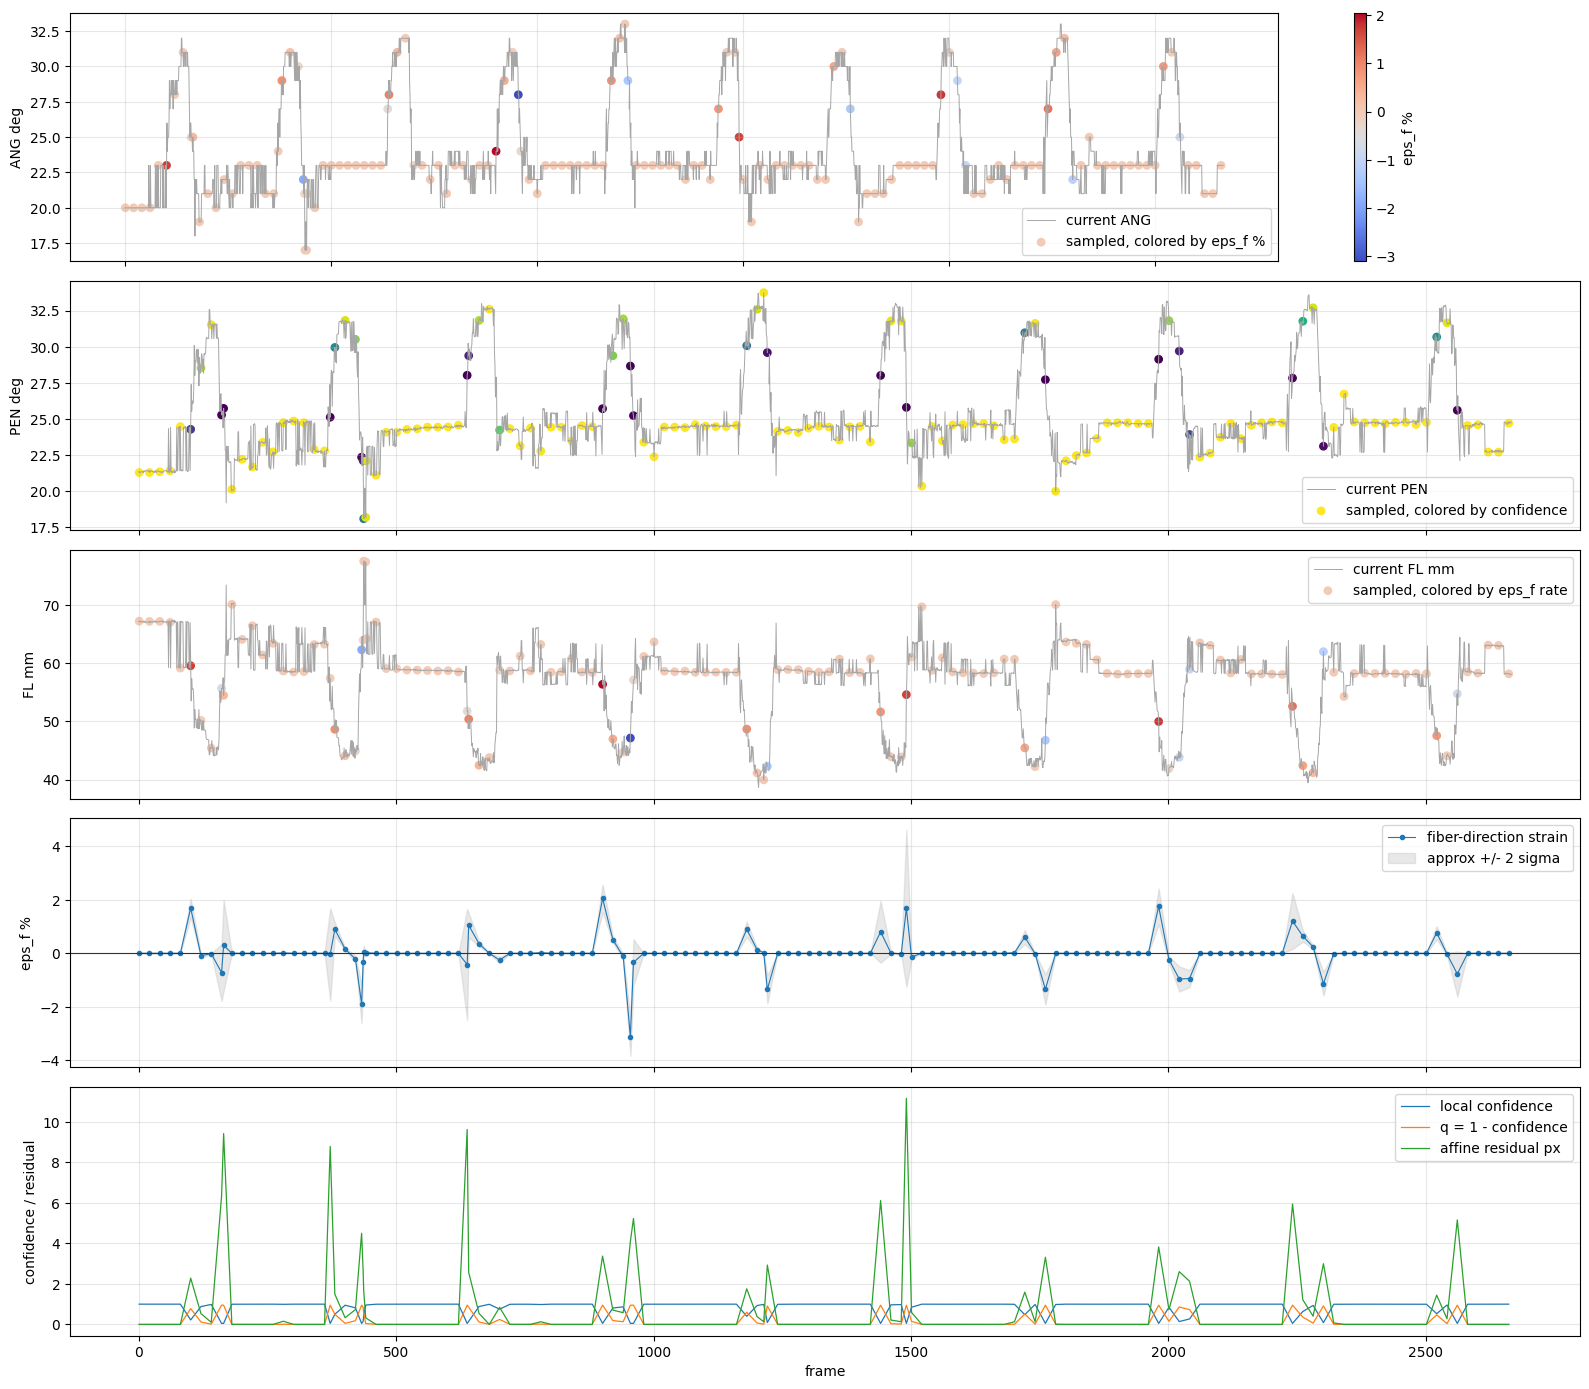

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

axes[0].plot(frame, raw_ang, color="0.65", linewidth=0.7, label="current ANG")
sc0 = axes[0].scatter(local_df["frame"], local_df["ANG_deg"], c=local_df["eps_f_percent"], cmap="coolwarm", s=28, label="sampled, colored by eps_f %")
axes[0].set_ylabel("ANG deg")
axes[0].legend(loc="best")
axes[0].grid(True, alpha=0.3)
plt.colorbar(sc0, ax=axes[0], label="eps_f %")

axes[1].plot(frame, raw_pen, color="0.65", linewidth=0.7, label="current PEN")
axes[1].scatter(local_df["frame"], local_df["PEN_deg"], c=local_df["local_confidence"], cmap="viridis", s=28, label="sampled, colored by confidence")
axes[1].set_ylabel("PEN deg")
axes[1].legend(loc="best")
axes[1].grid(True, alpha=0.3)

axes[2].plot(frame, raw_fl, color="0.65", linewidth=0.7, label=f"current FL {length_units}")
axes[2].scatter(local_df["frame"], local_df[f"FL_{length_units}"], c=local_df["eps_f_rate_percent_s"], cmap="coolwarm", s=28, label="sampled, colored by eps_f rate")
axes[2].set_ylabel(f"FL {length_units}")
axes[2].legend(loc="best")
axes[2].grid(True, alpha=0.3)

axes[3].plot(local_df["frame"], local_df["eps_f_percent"], marker=".", linewidth=0.8, label="fiber-direction strain")
axes[3].fill_between(
    local_df["frame"],
    local_df["eps_f_percent"] - 2 * local_df["sigma_eps_f_percent"],
    local_df["eps_f_percent"] + 2 * local_df["sigma_eps_f_percent"],
    color="0.75",
    alpha=0.35,
    label="approx +/- 2 sigma",
)
axes[3].axhline(0, color="0.2", linewidth=0.8)
axes[3].set_ylabel("eps_f %")
axes[3].legend(loc="best")
axes[3].grid(True, alpha=0.3)

axes[4].plot(local_df["frame"], local_df["local_confidence"], linewidth=0.9, label="local confidence")
axes[4].plot(local_df["frame"], local_df["q_out_of_plane_proxy"], linewidth=0.9, label="q = 1 - confidence")
axes[4].plot(local_df["frame"], local_df["affine_residual_sigma_px"], linewidth=0.9, label="affine residual px")
axes[4].set_ylabel("confidence / residual")
axes[4].set_xlabel("frame")
axes[4].legend(loc="best")
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

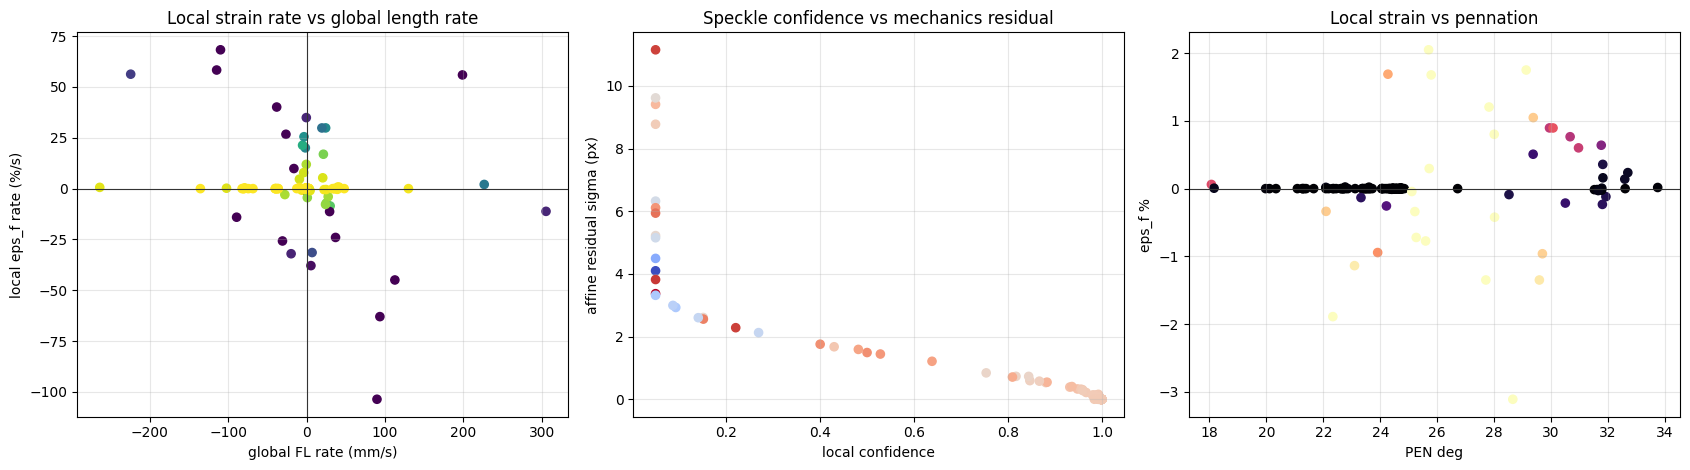

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].scatter(local_df["global_FL_rate"], local_df["eps_f_rate_percent_s"], c=local_df["local_confidence"], cmap="viridis", s=35)
axes[0].axhline(0, color="0.2", linewidth=0.8)
axes[0].axvline(0, color="0.2", linewidth=0.8)
axes[0].set_xlabel(f"global FL rate ({length_units}/s)")
axes[0].set_ylabel("local eps_f rate (%/s)")
axes[0].set_title("Local strain rate vs global length rate")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(local_df["local_confidence"], local_df["affine_residual_sigma_px"], c=local_df["eps_f_percent"], cmap="coolwarm", s=35)
axes[1].set_xlabel("local confidence")
axes[1].set_ylabel("affine residual sigma (px)")
axes[1].set_title("Speckle confidence vs mechanics residual")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(local_df["PEN_deg"], local_df["eps_f_percent"], c=local_df["q_out_of_plane_proxy"], cmap="magma", s=35)
axes[2].axhline(0, color="0.2", linewidth=0.8)
axes[2].set_xlabel("PEN deg")
axes[2].set_ylabel("eps_f %")
axes[2].set_title("Local strain vs pennation")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Inspect suspicious frames visually

The visual audit shows the fascicle ROI only.

- arrows: accepted local speckle displacements
- arrow color: NCC confidence
- strain scatter: local neighborhood affine strain estimate
- title: global affine strain and quality metrics

This helps separate bad visual detection from true fast contraction. True fast contraction should still look spatially coherent; bad tracking/out-of-plane motion often gives low confidence, few valid blocks, or a displacement field that cannot be fitted smoothly.

In [11]:
def local_strain_map(points, alpha_deg, radius_px=70.0, min_neighbors=8):
    if len(points) < min_neighbors:
        out = points.copy()
        out["local_eps_f"] = np.nan
        out["local_residual_px"] = np.nan
        return out

    xy = points[["x", "y"]].to_numpy(float)
    eps_values = []
    residual_values = []

    for i, (x0, y0) in enumerate(xy):
        dist = np.sqrt((xy[:, 0] - x0) ** 2 + (xy[:, 1] - y0) ** 2)
        mask = dist <= radius_px
        if int(mask.sum()) < min_neighbors:
            eps_values.append(np.nan)
            residual_values.append(np.nan)
            continue

        local = points.loc[mask].copy()
        local["ncc"] = local["ncc"] * np.exp(-(dist[mask] ** 2) / (2 * radius_px ** 2))
        fit = weighted_affine_fit(local, ridge=AFFINE_RIDGE)
        if fit is None:
            eps_values.append(np.nan)
            residual_values.append(np.nan)
            continue
        strain = strain_from_affine(fit["beta"], alpha_deg, fit["cov_beta"])
        eps_values.append(strain["eps_f"])
        residual_values.append(fit["residual_sigma_px"])

    out = points.copy()
    out["local_eps_f"] = eps_values
    out["local_residual_px"] = residual_values
    return out


def compute_pair_details(frame_idx):
    needed = [int(frame_idx) - 1, int(frame_idx)]
    missing = [f for f in needed if f not in frames_cache]
    extra = read_gray_frames(VIDEO_PATH, missing) if missing else {}
    local_cache = {**frames_cache, **extra}

    prev_crop = crop_roi(local_cache[int(frame_idx) - 1], rois["fascicle"])
    curr_crop = crop_roi(local_cache[int(frame_idx)], rois["fascicle"])
    points, total_blocks = local_block_matches(prev_crop, curr_crop, speckle_params)
    idx = result_index_for_frame(frame_idx)
    fit = weighted_affine_fit(points, ridge=AFFINE_RIDGE) if len(points) >= 4 else None
    strain = strain_from_affine(fit["beta"], raw_ang[idx], fit["cov_beta"]) if fit is not None else None
    strain_points = local_strain_map(points, raw_ang[idx], LOCAL_STRAIN_RADIUS_PX, MIN_LOCAL_NEIGHBORS) if len(points) else points
    return curr_crop, points, total_blocks, fit, strain, strain_points


def choose_example_frames(local_df, max_examples=6):
    candidates = []
    for f in [955, 1491]:
        if f in set(local_df["frame"].astype(int)):
            candidates.append(f)
    if len(local_df):
        for col, ascending in [
            ("local_confidence", True),
            ("affine_residual_sigma_px", False),
            ("q_out_of_plane_proxy", False),
            ("eps_f_rate_percent_s", False),
        ]:
            valid = local_df[np.isfinite(local_df[col])]
            if len(valid):
                candidates.append(int(valid.sort_values(col, ascending=ascending).iloc[0]["frame"]))
    out = []
    for f in candidates:
        if f not in out:
            out.append(f)
    return out[:max_examples]

example_frames = choose_example_frames(local_df)
print("Example frames:", example_frames)

Example frames: [955, 1491, 372, 901]


Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics/Test2_examples/Test2_local_mechanics_frame_000955.png


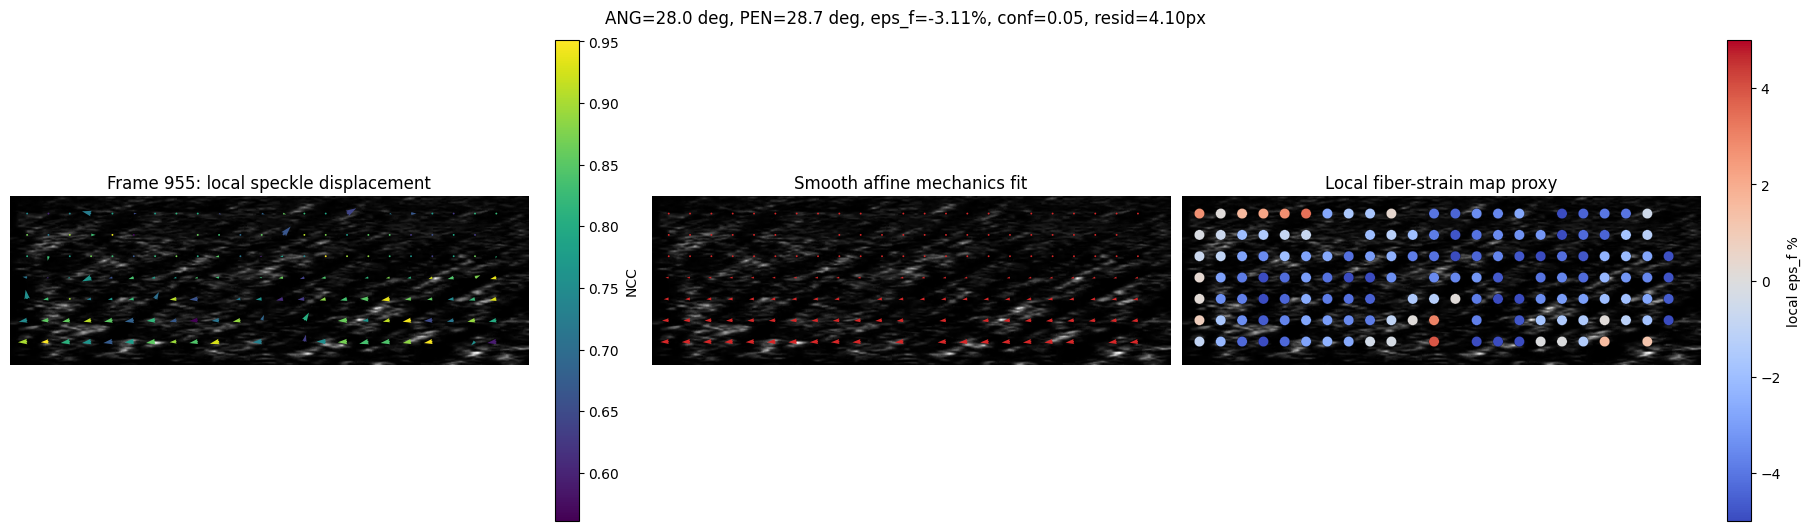

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics/Test2_examples/Test2_local_mechanics_frame_001491.png


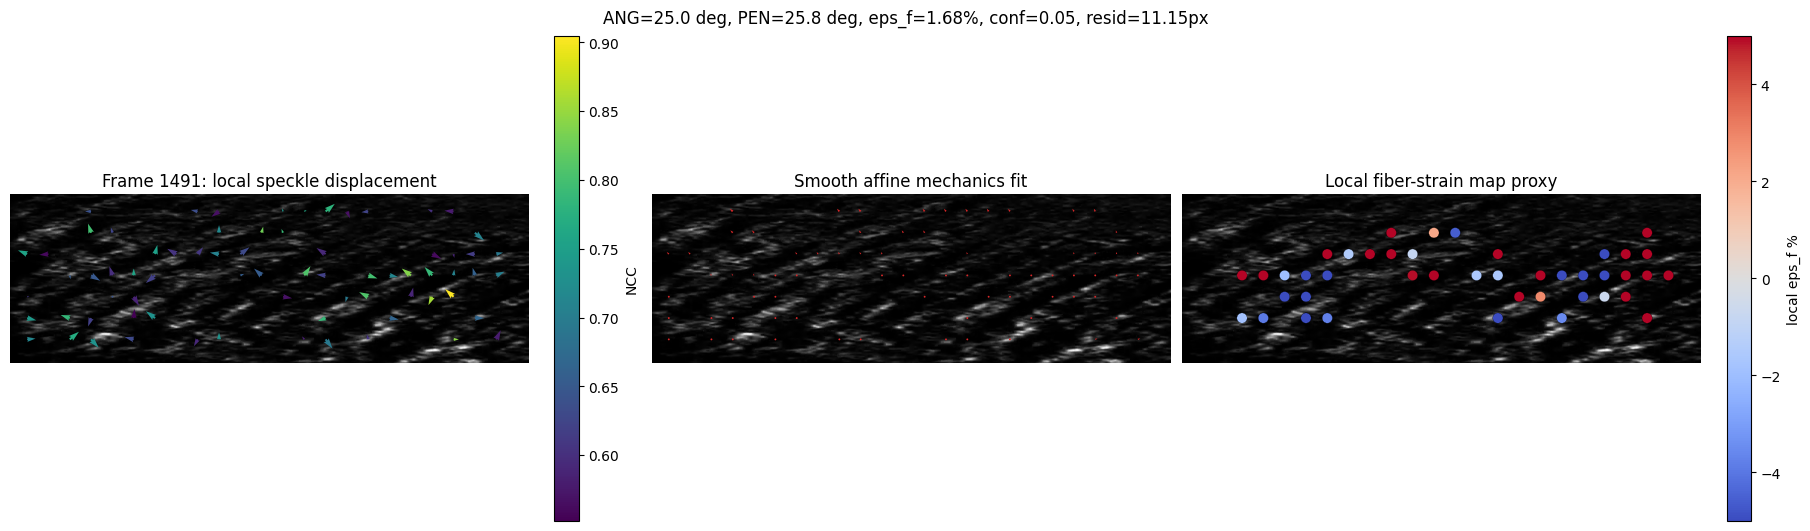

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics/Test2_examples/Test2_local_mechanics_frame_000372.png


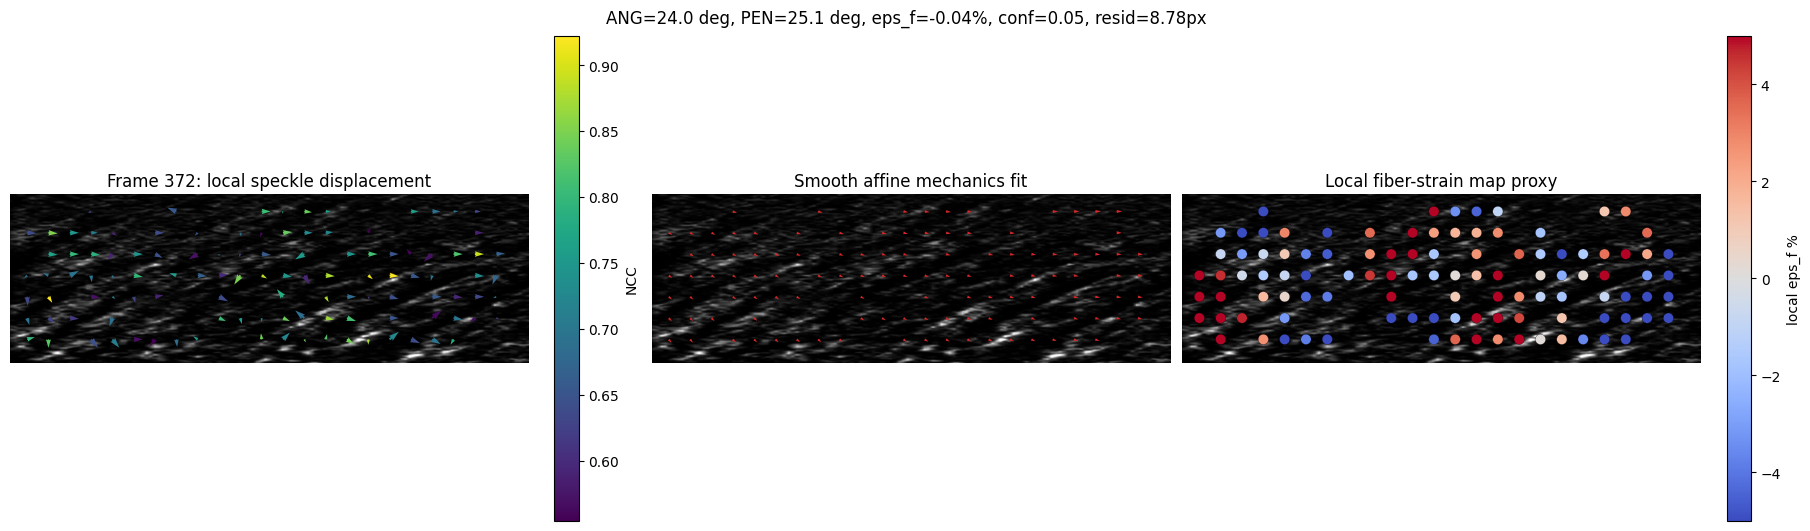

Saved: /Users/grosbedou/PycharmProjects/NDORMS/results/probabilistic_local_mechanics/Test2_examples/Test2_local_mechanics_frame_000901.png


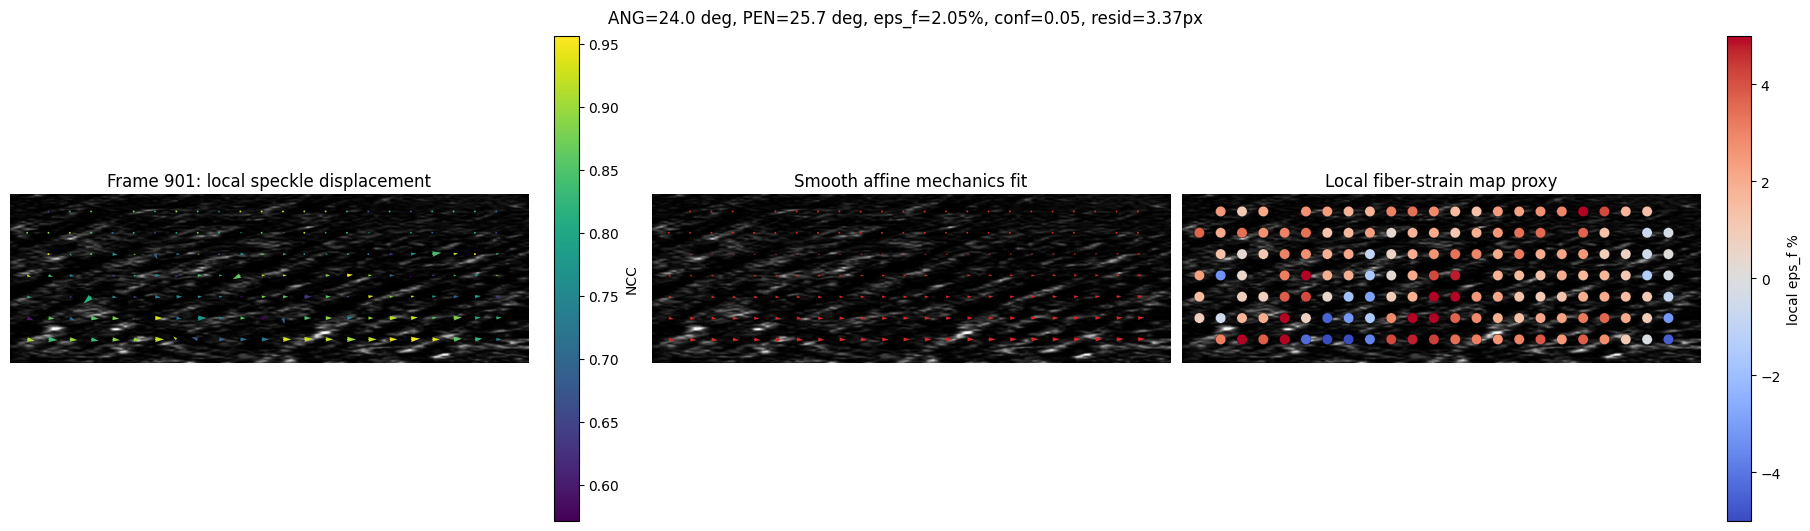

In [12]:
def plot_pair_audit(frame_idx, save=True):
    curr_crop, points, total_blocks, fit, strain, strain_points = compute_pair_details(frame_idx)
    idx = result_index_for_frame(frame_idx)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)

    axes[0].imshow(curr_crop, cmap="gray")
    if len(points):
        q = axes[0].quiver(
            points["x"],
            points["y"],
            points["dx"],
            points["dy"],
            points["ncc"],
            cmap="viridis",
            angles="xy",
            scale_units="xy",
            scale=1.0,
            width=0.004,
        )
        plt.colorbar(q, ax=axes[0], label="NCC")
    axes[0].set_title(f"Frame {frame_idx}: local speckle displacement")
    axes[0].set_axis_off()

    axes[1].imshow(curr_crop, cmap="gray")
    if fit is not None and len(points):
        x = points["x"].to_numpy(float)
        y = points["y"].to_numpy(float)
        x0 = x - fit["x_center"]
        y0 = y - fit["y_center"]
        A = np.column_stack([np.ones_like(x0), x0, y0])
        beta = fit["beta"]
        pred_dx = A @ beta[:3]
        pred_dy = A @ beta[3:]
        axes[1].quiver(x, y, pred_dx, pred_dy, color="tab:red", angles="xy", scale_units="xy", scale=1.0, width=0.004)
    axes[1].set_title("Smooth affine mechanics fit")
    axes[1].set_axis_off()

    axes[2].imshow(curr_crop, cmap="gray")
    if len(strain_points) and "local_eps_f" in strain_points:
        sc = axes[2].scatter(
            strain_points["x"],
            strain_points["y"],
            c=100.0 * strain_points["local_eps_f"],
            cmap="coolwarm",
            s=55,
            vmin=-5,
            vmax=5,
            edgecolors="black",
            linewidths=0.2,
        )
        plt.colorbar(sc, ax=axes[2], label="local eps_f %")
    axes[2].set_title("Local fiber-strain map proxy")
    axes[2].set_axis_off()

    if fit is not None and strain is not None:
        confidence, c_ncc, c_valid, c_motion = confidence_from_points(points, total_blocks, fit["residual_sigma_px"], speckle_params)
        title = (
            f"ANG={raw_ang[idx]:.1f} deg, PEN={raw_pen[idx]:.1f} deg, "
            f"eps_f={100*strain['eps_f']:.2f}%, conf={confidence:.2f}, "
            f"resid={fit['residual_sigma_px']:.2f}px"
        )
    else:
        title = f"Frame {frame_idx}: insufficient local mechanics data"
    fig.suptitle(title, fontsize=12)

    if save:
        out = EXAMPLE_DIR / f"{VIDEO_NAME}_local_mechanics_frame_{int(frame_idx):06d}.png"
        fig.savefig(out, dpi=160)
        print("Saved:", out)
    plt.show()

for f in example_frames:
    plot_pair_audit(int(f), save=True)

## 8. First-pass triage table

This is the table to look at after the plots.

Useful interpretation:

- low `local_confidence` + high `q_out_of_plane_proxy`: possible out-of-plane motion or poor speckle tracking
- high `affine_residual_sigma_px`: local measurements disagree with a smooth tissue deformation
- large `eps_f_rate_percent_s` with good confidence and low residual: likely true fast contraction
- large `eps_f_rate_percent_s` with poor confidence/residual: suspicious measurement
- frame 955 should be interpreted using final `ANG/PEN/FL`, not the old selected debug line from previous notebooks

In [13]:
triage_cols = [
    "frame",
    "time_s",
    "ANG_deg",
    "PEN_deg",
    f"FL_{length_units}",
    "local_confidence",
    "q_out_of_plane_proxy",
    "valid_fraction",
    "affine_residual_sigma_px",
    "eps_f_percent",
    "eps_f_rate_percent_s",
    "sigma_eps_f_percent",
    "global_FL_rate",
    "mechanics_warning",
    "warning_reason",
]

interesting = pd.concat([
    local_df.sort_values("local_confidence", ascending=True).head(8),
    local_df.sort_values("affine_residual_sigma_px", ascending=False).head(8),
    local_df.reindex(local_df["eps_f_rate_percent_s"].abs().sort_values(ascending=False).index).head(8),
], ignore_index=True).drop_duplicates("frame")

interesting = interesting.sort_values(["mechanics_warning", "q_out_of_plane_proxy", "affine_residual_sigma_px"], ascending=[False, False, False])
display(interesting[triage_cols].head(20))

,frame,time_s,ANG_deg,PEN_deg,FL_mm,local_confidence,q_out_of_plane_proxy,valid_fraction,affine_residual_sigma_px,eps_f_percent,eps_f_rate_percent_s,sigma_eps_f_percent,global_FL_rate,mechanics_warning,warning_reason
1,1491,44.719715,25.0,25.787985,54.627922,0.050000,0.950000,0.447205,11.154648,1.677231,55.917078,1.467010,198.871426,True,low local confidence; poor smooth affine fit
9,638,19.135599,27.0,28.014881,51.789700,0.050000,0.950000,0.621118,9.620040,-0.421674,-14.059062,1.035832,-89.201526,True,low local confidence; poor smooth affine fit
10,165,4.948862,25.0,25.718571,54.505543,0.050000,0.950000,0.770186,9.413822,0.296151,9.873984,0.846887,-16.120318,True,low local confidence; poor smooth affine fit
0,372,11.157434,24.0,25.108286,57.436352,0.050000,0.950000,0.701863,8.778838,-0.042816,-1.427542,0.862859,0.114785,True,low local confidence; poor smooth affine fit
12,161,4.828889,25.0,25.262075,55.712818,0.050000,0.950000,0.900621,6.324991,-0.720265,-24.014402,0.528791,36.977742,True,low local confidence; poor smooth affine fit
5,1441,43.220058,27.0,28.001768,51.647964,0.050000,0.950000,0.857143,6.113288,0.801650,26.729566,0.574556,-26.276414,True,low local confidence; poor smooth affine fit
3,2241,67.214539,27.0,27.820259,52.616482,0.050000,0.950000,0.888199,5.941623,1.203485,40.128015,0.520123,-38.079864,True,low local confidence; poor smooth affine fit
15,961,28.823370,24.0,25.215149,57.152306,0.050000,0.950000,0.931677,5.224151,-0.338515,-11.286438,0.429985,29.417424,True,low local confidence; poor smooth affine fit
4,2561,76.812332,25.0,25.592165,54.770657,0.050000,0.950000,0.931677,5.155145,-0.772231,-25.748621,0.419161,-30.711524,True,low local confidence; poor smooth affine fit
18,433,12.987013,22.0,22.333731,62.351513,0.050000,0.950000,0.906832,4.496395,-1.888348,-62.959503,0.354912,93.542067,True,low local confidence; poor smooth affine fit


## 9. What would change next if this variant is promising

This notebook is a prototype. The package-level version should probably add these pieces later:

1. expose a package function that returns local block matches, not only global speckle confidence
2. add a small `local_mechanics.py` module for affine/reduced-basis displacement fitting
3. store local mechanics outputs as optional diagnostics alongside final `ANG/PEN/FL`
4. only after validation, decide whether `eps_f`, strain rate, and uncertainty should become official outputs
5. leave the current UltraTimTrack-compatible final path stable while this develops

A practical success criterion for this notebook:

- during visible contraction, `eps_f` or `eps_f_rate` should change coherently with `FL` shortening/lengthening
- suspicious frames should have either low confidence, few valid blocks, high affine residual, or high uncertainty
- examples with good confidence should look spatially coherent in the quiver plots

If these three things happen, we are ready to move the local block-match and affine mechanics helpers into `ultrasound_tracker`.